In [1]:
# Librerias necesarias
import os
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
#from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from datetime import datetime
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate, Resizing, UpSampling2D
from tensorflow.keras.layers import  Flatten, Dense,BatchNormalization,MultiHeadAttention, LayerNormalization, Permute, Add,Reshape,GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.activations import gelu
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from skimage import exposure
from PIL import Image
import cv2
from scipy import ndimage
import matplotlib.pyplot as plt


## Cargar imágenes

In [2]:

# Define las rutas a las carpetas
base_dir = 'datasetV3'
categorias = ['normal','benigno', 'maligno']

datos = []
etiquetas = []


In [4]:
def read_imageResize_with_labels(dir='..\database\datasetV3'):
    """
    Lee imágenes de un directorio, las redimensiona a 224x224 píxeles y las etiqueta según 
    la subcarpeta en la que se encuentran. Las imágenes son procesadas en escala de grises.

    Parámetros:
    dir (str): La ruta del directorio principal que contiene las subcarpetas con las imágenes. 
               Las subcarpetas deben llamarse 'normal', 'benigno' y 'maligno' para que 
               las etiquetas se asignen correctamente. Las subcarpetas no definidas 
               recibirán una etiqueta de -1.

    Retorno:
    tuple: Una tupla que contiene dos elementos:
        - np.array: Un array de NumPy con las imágenes redimensionadas.
        - list: Una lista de etiquetas correspondientes a las imágenes.
    """
    labels = []
    imgs = []
    for subfolder in os.listdir(dir):
        
        subfolder_path = os.path.join(dir,subfolder)
        for name_image in os.listdir(subfolder_path):
            bandera = False    

            # Obtener la etiqueta desde el nombre de la subcarpeta
            if subfolder == 'normal':
                bandera = True
                labels.append(0)
            elif subfolder == 'benigno':
                bandera = True
                labels.append(1)
            elif subfolder == 'maligno':
                bandera = True
                labels.append(2)

            if bandera:    
           
                # Obtenemos la ruta de la imagen
                image_path = os.path.join(subfolder_path,name_image)
                
                # Read the image using TensorFlow for GPU acceleration
                image = cv2.imread(image_path,cv2.IMREAD_COLOR)
            
                imgs.append(image)
    
    return  np.array(imgs), labels

In [ ]:
# Leer las imagenes originales con sus etiquetas

imgs, labels = read_imageResize_with_labels(dir='../database/datasetV5')

In [9]:
# Comprobar la cantidad
print(imgs.shape)
print(len(labels))

(5985, 224, 224, 3)
5985


In [10]:
# Verificar normalizacion
unicos = np.unique(imgs[0])
max(unicos)

255

# Preparación conjuntos de train, test, val

In [ ]:
image_data = np.array(imgs)
labels = np.array(labels)

X_train=[]
X_test=[]
y_train=[]
y_test = []

In [14]:
del imgs

In [15]:

# Dividir en conjuntos de entrenamiento (70%) y temporal (30%), manteniendo el balance de etiquetas
X_train, X_temp, y_train, y_temp = train_test_split(image_data, labels, test_size=0.3, stratify=labels, random_state=42)

# Dividir el conjunto temporal en validación y prueba, manteniendo el balance de etiquetas
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

from collections import Counter 
# Verificar las proporciones en los conjuntos de entrenamiento, validación y prueba
print("Proporciones en el conjunto de entrenamiento:", Counter(y_train))
print("Proporciones en el conjunto de validación:", Counter(y_val))
print("Proporciones en el conjunto de prueba:", Counter(y_test))


Proporciones en el conjunto de entrenamiento: Counter({0: 1397, 1: 1396, 2: 1396})
Proporciones en el conjunto de validación: Counter({2: 300, 1: 299, 0: 299})
Proporciones en el conjunto de prueba: Counter({1: 300, 2: 299, 0: 299})


In [16]:
del image_data

In [18]:
print("Forma de X_train:", X_train.shape)
print("Forma de X_val:", X_val.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_val:", y_val.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (4189, 224, 224, 3)
Forma de X_val: (898, 224, 224, 3)
Forma de X_test: (898, 224, 224, 3)
Forma de y_train: (4189,)
Forma de y_val: (898,)
Forma de y_test: (898,)


In [20]:
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical

# Convertir las etiquetas a codificación one-hot
y_train_one_hot = to_categorical(y_train, num_classes=3)
y_test_one_hot = to_categorical(y_test, num_classes=3)
y_val_one_hot = to_categorical(y_val, num_classes=3)

# Crea generadores de datos de imagen con aumento de datos
train_datagen = ImageDataGenerator(
    rescale=1./255  # Reescala las imágenes por el factor dado
)

test_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

# Crea generadores que suministrarán los datos al modelo durante el entrenamiento
train_generator = train_datagen.flow(
    X_train,
    y_train_one_hot,
    batch_size=32
)

test_generator = test_datagen.flow(
    X_test,
    y_test_one_hot,
    batch_size=32
)

val_generator = val_datagen.flow(
    X_val,
    y_val_one_hot,
    batch_size=32
)


# Modelo

In [24]:
#Early stopping para que se detenga el entranamiento si a las 5 épocas no mejora el accuracy

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True
)


In [25]:

# callback para detener el entrenamiento si se alcanza el accuracy deseado
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('val_accuracy') > 0.84):
      print("Accuracy alcanzado")
      self.model.stop_training = True


In [26]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# Cargar VGG16 pre-entrenado (sin las capas densas)
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelar todos los bloques excepto el último (Bloque 5)
for layer in vgg_model.layers:
    if 'block5' not in layer.name:   # Congelar todo menos las capas del último bloque
        layer.trainable = False
    else:
        layer.trainable = True       # Descongelar solo el bloque 5

# Añadir las capas personalizadas
x = Flatten()(vgg_model.output)
x = Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.0001))(x)
x = Dropout(0.3)(x)
prediction = Dense(3, activation='softmax')(x)

model = Model(inputs=vgg_model.input, outputs=prediction)

# (Opcional) tasa de aprendizaje más baja para las capas descongeladas
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=1e-5)  # Más bajo que el usado en las capas nuevas

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

# Entrenar modelo

In [27]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [28]:
stop = myCallback()
with tf.device('/GPU:0'):
    history = model.fit(train_generator,
                        epochs=50,
                        validation_data=val_generator,
                        verbose=1,
                        callbacks=[early_stopping,stop])

Epoch 1/50
131/131 [==============================] - 66s 314ms/step - loss: 1.2664 - accuracy: 0.5889 - val_loss: 0.6271 - val_accuracy: 0.7216
Epoch 2/50
131/131 [==============================] - 32s 244ms/step - loss: 0.5626 - accuracy: 0.7176 - val_loss: 0.5321 - val_accuracy: 0.7316
Epoch 3/50
131/131 [==============================] - 29s 222ms/step - loss: 0.5093 - accuracy: 0.7329 - val_loss: 0.5435 - val_accuracy: 0.7183
Epoch 4/50
131/131 [==============================] - 31s 239ms/step - loss: 0.5208 - accuracy: 0.7407 - val_loss: 0.5203 - val_accuracy: 0.7517
Epoch 5/50
131/131 [==============================] - 31s 233ms/step - loss: 0.4712 - accuracy: 0.7653 - val_loss: 0.5102 - val_accuracy: 0.7684
Epoch 6/50
131/131 [==============================] - 30s 231ms/step - loss: 0.5243 - accuracy: 0.7696 - val_loss: 0.5084 - val_accuracy: 0.7650
Epoch 7/50
131/131 [==============================] - 31s 236ms/step - loss: 0.4522 - accuracy: 0.7813 - val_loss: 0.4825 - val_ac

In [29]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy}")

29/29 [==============================] - 6s 203ms/step - loss: 0.4296 - accuracy: 0.8040
Test Accuracy: 0.8040089011192322


In [30]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [31]:
# Visualización de curvas de pérdida y precisión
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    
    plt.show()

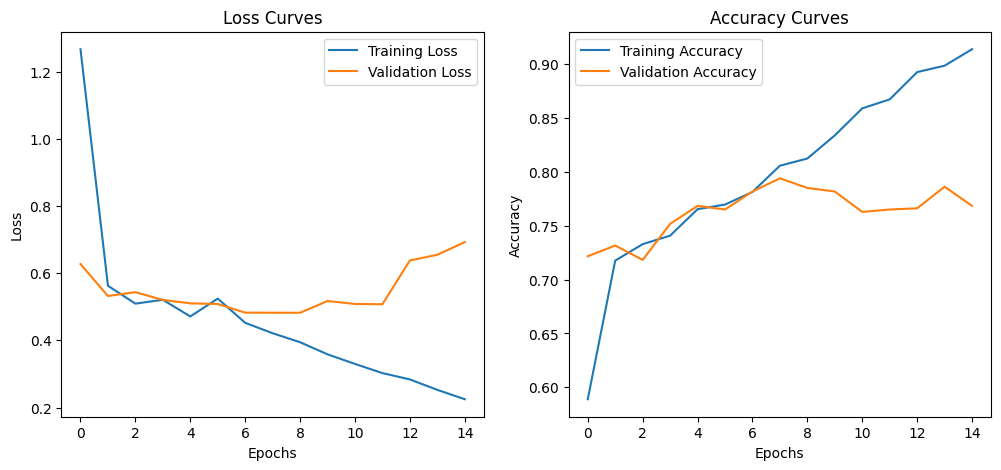

In [32]:
plot_training_history(history)

# Métricas de desempeño

29/29 [==============================] - 6s 178ms/step


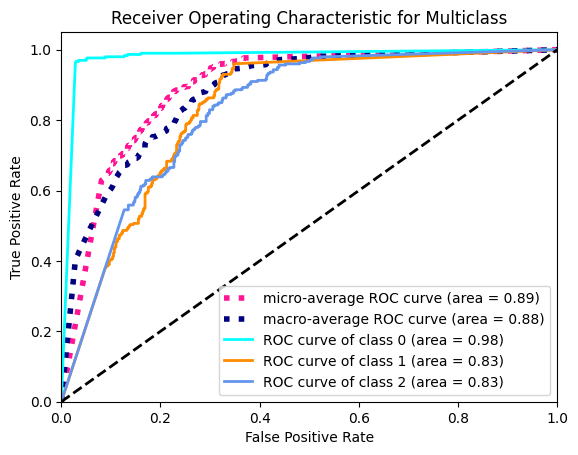

AUC for each class:
Class 0: 0.98
Class 1: 0.83
Class 2: 0.83
Micro-average AUC: 0.89
Macro-average AUC: 0.88


In [33]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


y_pred_prob = model.predict(X_test)

n_classes = 3
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Calcula ROC curve y ROC area para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcula la media micro y macro para ROC curve y ROC area
# Micro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot de las curvas ROC para cada clase y la media
plt.figure()
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4,
         label=f'micro-average ROC curve (area = {roc_auc["micro"]:.2f})')
plt.plot(fpr["macro"], tpr["macro"], color='navy', linestyle=':', linewidth=4,
         label=f'macro-average ROC curve (area = {roc_auc["macro"]:.2f})')

colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multiclass')
plt.legend(loc='lower right')
plt.show()

# Imprimir los valores de AUC
print(f'AUC for each class:')
for i in range(n_classes):
    print(f'Class {i}: {roc_auc[i]:.2f}')
print(f'Micro-average AUC: {roc_auc["micro"]:.2f}')
print(f'Macro-average AUC: {roc_auc["macro"]:.2f}')


In [34]:
import json

# Guardar las métricas AUC macro en un archivo JSON
metrics = {"model_name": "Modelo_VGG16", "macro_auc": roc_auc["macro"]}

with open(f"model_metrics_{metrics['model_name']}.json", "w") as file:
    json.dump(metrics, file)


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Genera las predicciones del modelo
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convierte las predicciones en clases
y_true = []
for i in range(len(test_generator)):
    _, labels = test_generator[i]
    y_true.extend(labels.argmax(axis=1))  # Convierte a clases si es necesario

y_true = np.array(y_true)

# Obtén el reporte de clasificación
print("Classification Report:\n", classification_report(y_true, y_pred_classes))

29/29 [==============================] - 5s 170ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.31      0.31       299
           1       0.35      0.37      0.36       300
           2       0.37      0.33      0.35       299

    accuracy                           0.34       898
   macro avg       0.34      0.34      0.34       898
weighted avg       0.34      0.34      0.34       898



Matriz de Confusión:
[[290   6   3]
 [ 16 172 112]
 [ 13  95 191]]


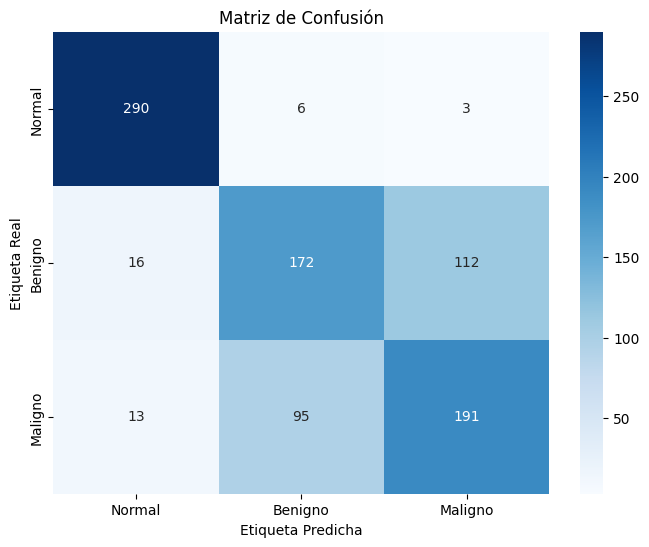

In [36]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Convierte las probabilidades en etiquetas de clase usando argmax
y_pred_class = np.argmax(y_pred_prob, axis=1)

# Paso 5: Calcula la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_class)

# Paso 6: Muestra la matriz de confusión
print("Matriz de Confusión:")
print(conf_matrix)

# Paso 7: Visualiza la matriz de confusión usando una gráfica de calor (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Benigno', 'Maligno'], yticklabels=['Normal', 'Benigno', 'Maligno'])
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión')
plt.show()

# Validación de varios runs (20)

## VGG 16 FREEZED LAYERS

In [38]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models       import Model
from tensorflow.keras.layers       import Flatten, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
import numpy as np
import tensorflow as tf
import gc

validation_accuracies = []
test_accuracies = []

for run in range(20):
    # 1) Load fresh base VGG16 (no dense head), freeze conv layers
    base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
    
    for layer in base.layers:
        if 'block5' not in layer.name:   # Congelar todo menos las capas del último bloque
            layer.trainable = False
        else:
            layer.trainable = True       

    # 2) Build the classification head
    x = Flatten()(base.output)
    x = Dense(
        1024,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = Dropout(0.3)(x)
    preds = Dense(3, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=preds)

    # 3) Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # 4) Train with early stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True
    )

    with tf.device('/GPU:0'):
        history = model.fit(
            train_generator,
            epochs=50,
            validation_data=val_generator,
            verbose=0,
            callbacks=[early_stopping]
        )

    # 5) Record best validation accuracy
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    test_accuracies.append(test_acc)
    print(f"Run {run+1}: Test accuracy = {test_acc:.4f}")

    # 6) Memory cleanup
    K.clear_session()
    del model, base
    gc.collect()

# Final summary
print("Test accuracies over 20 runs:", test_accuracies)
print(f"Mean test accuracy: {np.mean(test_accuracies):.4f}")
print(f"Std test accuracy:  {np.std(test_accuracies):.4f}")


Run 1: Test accuracy = 0.3330
Run 2: Test accuracy = 0.8051
Run 3: Test accuracy = 0.3330
Run 4: Test accuracy = 0.3330
Run 5: Test accuracy = 0.7595
Run 6: Test accuracy = 0.3330
Run 7: Test accuracy = 0.3341
Run 8: Test accuracy = 0.3330
Run 9: Test accuracy = 0.3330
Run 10: Test accuracy = 0.8051
Run 11: Test accuracy = 0.8129
Run 12: Test accuracy = 0.3330
Run 13: Test accuracy = 0.7862
Run 14: Test accuracy = 0.7996
Run 15: Test accuracy = 0.7984
Run 16: Test accuracy = 0.7817
Run 17: Test accuracy = 0.3330
Run 18: Test accuracy = 0.7595
Run 19: Test accuracy = 0.3330
Run 20: Test accuracy = 0.7951
Test accuracies over 20 runs: [0.33296212553977966, 0.8051224946975708, 0.33296212553977966, 0.33296212553977966, 0.7594654560089111, 0.33296212553977966, 0.3340757191181183, 0.33296212553977966, 0.33296212553977966, 0.8051224946975708, 0.8129175901412964, 0.33296212553977966, 0.7861915230751038, 0.7995545864105225, 0.7984409928321838, 0.781737208366394, 0.33296212553977966, 0.759465456

##  Resnet 50 FREEZED LAYERS

In [40]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models       import Model
from tensorflow.keras.layers       import Flatten, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
import numpy as np
import tensorflow as tf
import gc

validation_accuracies = []
test_accuracies = []

for run in range(20):
    # 1) Load fresh base VGG16 (no dense head), freeze conv layers
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    
    for layer in base.layers:
        if 'conv5' not in layer.name:  # Congela todos los bloques excepto conv5_x
            layer.trainable = False
        else:
            layer.trainable = True      

    # 2) Build the classification head
    x = Flatten()(base.output)
    x = Dense(
        1024,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = Dropout(0.3)(x)
    preds = Dense(3, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=preds)

    # 3) Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # 4) Train with early stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True
    )

    with tf.device('/GPU:0'):
        history = model.fit(
            train_generator,
            epochs=50,
            validation_data=val_generator,
            verbose=0,
            callbacks=[early_stopping]
        )

    # 5) Record best validation accuracy
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    test_accuracies.append(test_acc)
    print(f"Run {run+1}: Test accuracy = {test_acc:.4f}")

    # 6) Memory cleanup
    K.clear_session()
    del model, base
    gc.collect()

# Final summary
print("Test accuracies over 20 runs:", test_accuracies)
print(f"Mean test accuracy: {np.mean(test_accuracies):.4f}")
print(f"Std test accuracy:  {np.std(test_accuracies):.4f}")


Run 1: Test accuracy = 0.7350
Run 2: Test accuracy = 0.7428
Run 3: Test accuracy = 0.7116
Run 4: Test accuracy = 0.6514
Run 5: Test accuracy = 0.7261
Run 6: Test accuracy = 0.7350
Run 7: Test accuracy = 0.7116
Run 8: Test accuracy = 0.7517
Run 9: Test accuracy = 0.6704
Run 10: Test accuracy = 0.7060
Run 11: Test accuracy = 0.6837
Run 12: Test accuracy = 0.7483
Run 13: Test accuracy = 0.7483
Run 14: Test accuracy = 0.7105
Run 15: Test accuracy = 0.7082
Run 16: Test accuracy = 0.7082
Run 17: Test accuracy = 0.7739
Run 18: Test accuracy = 0.7428
Run 19: Test accuracy = 0.7450
Run 20: Test accuracy = 0.7350
Test accuracies over 20 runs: [0.7349665760993958, 0.7427616715431213, 0.711581289768219, 0.6514476537704468, 0.7260578870773315, 0.7349665760993958, 0.711581289768219, 0.7516703605651855, 0.6703786253929138, 0.7060133814811707, 0.6837416291236877, 0.7483296394348145, 0.7483296394348145, 0.7104676961898804, 0.7082405090332031, 0.7082405090332031, 0.7739421129226685, 0.7427616715431213, 

## EfficientNet B2 FREEZED LAYERS

In [41]:
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.models       import Model
from tensorflow.keras.layers       import Flatten, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
import numpy as np
import tensorflow as tf
import gc

validation_accuracies = []
test_accuracies = []

for run in range(20):
    # 1) Load fresh base VGG16 (no dense head), freeze conv layers
    base = EfficientNetB2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    
    for layer in base.layers:
        if 'block6' not in layer.name and 'block7' not in layer.name:
            layer.trainable = False
        else:
            layer.trainable = True     

    # 2) Build the classification head
    x = Flatten()(base.output)
    x = Dense(
        1024,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = Dropout(0.3)(x)
    preds = Dense(3, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=preds)

    # 3) Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # 4) Train with early stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True
    )

    with tf.device('/GPU:0'):
        history = model.fit(
            train_generator,
            epochs=50,
            validation_data=val_generator,
            verbose=0,
            callbacks=[early_stopping]
        )

    # 5) Record best validation accuracy
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    test_accuracies.append(test_acc)
    print(f"Run {run+1}: Test accuracy = {test_acc:.4f}")

    # 6) Memory cleanup
    K.clear_session()
    del model, base
    gc.collect()

# Final summary
print("Test accuracies over 20 runs:", test_accuracies)
print(f"Mean test accuracy: {np.mean(test_accuracies):.4f}")
print(f"Std test accuracy:  {np.std(test_accuracies):.4f}")


Run 1: Test accuracy = 0.7450
Run 2: Test accuracy = 0.3474
Run 3: Test accuracy = 0.7450
Run 4: Test accuracy = 0.7428
Run 5: Test accuracy = 0.7416
Run 6: Test accuracy = 0.7428
Run 7: Test accuracy = 0.3330
Run 8: Test accuracy = 0.7405
Run 9: Test accuracy = 0.3363
Run 10: Test accuracy = 0.7416
Run 11: Test accuracy = 0.7439
Run 12: Test accuracy = 0.7272
Run 13: Test accuracy = 0.7506
Run 14: Test accuracy = 0.7394
Run 15: Test accuracy = 0.7517
Run 16: Test accuracy = 0.7327
Run 17: Test accuracy = 0.3330
Run 18: Test accuracy = 0.3330
Run 19: Test accuracy = 0.3575
Run 20: Test accuracy = 0.3330
Test accuracies over 20 runs: [0.7449888586997986, 0.3474387526512146, 0.7449888586997986, 0.7427616715431213, 0.7416480779647827, 0.7427616715431213, 0.33296212553977966, 0.7405345439910889, 0.33630290627479553, 0.7416480779647827, 0.74387526512146, 0.7271714806556702, 0.7505567669868469, 0.7394209504127502, 0.7516703605651855, 0.7327394485473633, 0.33296212553977966, 0.332962125539779